In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR, StepLR
import torchvision.transforms.v2 as transforms_v2
from torchvision import datasets
import matplotlib.pyplot as plt

#CONFIGURATION
SEEDS = [1, 3, 5]
BATCH_SIZE = 100
EPOCHS = 100
LEARNING_RATE = 0.01
MOMENTUM = 0.9
NORMALIZATION = "zscore" #"minmax" or "zscore"
INITIALIZATION = "normal" #"he","normal", or "uniform"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CROP_PADDING_NUM = 2
N_FIRST_LAYER = 128
N_SECOND_LAYER = 64
N_THIRD_LAYER = 32
OVERFITTING_DETECTION_PARAMETER = 10

DROPOUT = False
DROPOUT_VALUE = 0.25

#adaptive learning rate
ALR = "None" #"exp_decay", #"factor_decay" #"None"
GAMMA = 0.95 #rate of exp decay

sigma = 1.0

augmenter = transforms_v2.Compose([
    transforms_v2.RandomHorizontalFlip(p=0.5),
    transforms_v2.RandomCrop(28, padding=CROP_PADDING_NUM),
])

train_part = datasets.FashionMNIST(root='./data', train=True, download=True)
test_part = datasets.FashionMNIST(root='./data', train=False, download=True)

X_train_raw = train_part.data
Y_train_raw = train_part.targets
X_test_raw = test_part.data
Y_test_raw = test_part.targets

X = torch.cat([X_train_raw, X_test_raw], dim=0)
Y = torch.cat([Y_train_raw, Y_test_raw], dim=0)


In [23]:
#DEFINE NN CLASS
class NeuralNetwork(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear_relu_stack = None
    if DROPOUT:
      self.linear_relu_stack = torch.nn.Sequential(
        torch.nn.Linear(28*28,N_FIRST_LAYER),
        torch.nn.ReLU(),
        torch.nn.Linear(N_FIRST_LAYER,N_SECOND_LAYER),
        torch.nn.ReLU(),
        torch.nn.Dropout(DROPOUT_VALUE),
        torch.nn.Linear(N_SECOND_LAYER,N_THIRD_LAYER),
        torch.nn.ReLU(),
        torch.nn.Dropout(DROPOUT_VALUE),
        torch.nn.Linear(N_THIRD_LAYER,10)
      )
    else:
      self.linear_relu_stack = torch.nn.Sequential(
      torch.nn.Linear(28*28,N_FIRST_LAYER),
      torch.nn.ReLU(),
      torch.nn.Linear(N_FIRST_LAYER,N_SECOND_LAYER),
      torch.nn.ReLU(),
      torch.nn.Dropout(DROPOUT_VALUE),
      torch.nn.Linear(N_SECOND_LAYER,N_THIRD_LAYER),
      torch.nn.ReLU(),
      torch.nn.Dropout(DROPOUT_VALUE),
      torch.nn.Linear(N_THIRD_LAYER,10)
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

#INITIALIZATION
"""this function checks if the current layer is a linear layer, if it is,
the weights are changed to He init. m represents current layer"""
def weights_init(m):
  if isinstance(m, torch.nn.Linear):
    if(INITIALIZATION == "he"):
      torch.nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
    elif(INITIALIZATION == "normal"):
      torch.nn.init.normal_(m.weight,mean=0,std=0.05)
    else:
      fanin, __ = torch.nn.init._calculate_fan_in_and_fan_out(m.weight)
      torch.nn.init.uniform_(m.weight,a= -1/np.sqrt(fanin),b=1/np.sqrt(fanin))


#TRACK DATA
results = {
    "train_loss": [],
    "valid_loss": [],
    "train_acc": [],
    "valid_acc": [],
    "test_acc": [],
    "converge_time": [],
}

"""this function gets loss and accuracy with a given dataset and labels"""
def eval_model(x_set,y_set,model,criterion):
  with torch.no_grad(): #this disables gradient calculations
    x_set = x_set.to(DEVICE)
    y_set = y_set.to(DEVICE)

    #run through model and get predictions
    outputs = model(x_set)
    loss = criterion(outputs, y_set)
    probab = torch.nn.Softmax(dim=1)(outputs)
    predictions = probab.argmax(1)

    #take off GPU to use numpy
    numpy_pred = predictions.cpu().detach().numpy()
    y_valid_numpy = y_set.cpu().detach().numpy()

    #calc and return the accuracy and loss
    acc = numpy_pred == y_valid_numpy
    return loss.item(),acc.astype(int).sum()/len(acc)




In [3]:
  #SPLIT DATA INTO SPECIFIED REGIONS
  test_set = X[0:7000] #10% of df, 7k data points
  y_test = Y[0:7000]

  valid_set = X[7000:14000] #10% of df, 7k data points
  y_valid = Y[7000:14000]

  train_set = X[14000:] #80% of df, 56k data points
  y_train = Y[14000:]

  #split training again for labeled/unlabeled
  unlabelled_train_set = train_set[0:44800] #80% unlabelled
  y_unlabelled_train = y_train[0:44800]

  labelled_train_set = train_set[44800:] #20% labelled
  y_labelled_train = y_train[44800:]

In [4]:
#convert to numpy
unlabelled_train_set = unlabelled_train_set.cpu().detach().numpy()
labelled_train_set = labelled_train_set.cpu().detach().numpy()
y_labelled_train = y_labelled_train.cpu().detach().numpy()


In [ ]:
#Since these take quite some time the prints help gauge progress
new_label_indices = None #will store the pseudolabels that we say are good enough to be treated as real labels
new_y = None
for subset_split in range(2): #we need exactly 4 subsets of the same size to label all the data
  print(f"starting {subset_split+1}th subset")
  subset = np.concatenate((labelled_train_set,unlabelled_train_set[11200*(subset_split):11200*(subset_split+1)]),axis=0)
  X = subset.reshape(subset.shape[0],784,1).squeeze()
  X = X.astype('float32')/255 #normalize and we are using float32 to save space
  subset = None # to save space

  T = np.zeros((22400,22400))
  #set up Y
  y =  np.eye(10)[y_labelled_train] #one hot encoding of the labelled dat
  y = np.concatenate((y,np.zeros((11200,10))),axis=0) #concat the unpredicted labels

  #this way of computing euclidean distance is from "Euclidean Distance Trick" referred in report
  row_sums = np.sum(X**2, axis=1).reshape(-1, 1)
  dists = row_sums + row_sums.T - 2 * np.dot(X, X.T)

  T = np.exp(-dists / (2 * sigma**2)) #kernel

  print(f"training on the {subset_split+1}th subset")
  #training loop
  static_labels = np.eye(10)[y_labelled_train]
  for i in range(100):
    #propagate the labels
    y = T @ y

    #renormalize y, basically make sure each of the rows represent a valid probability distribution
    y = y / np.sum(y, axis=1, keepdims=True)

    #reset known labels
    y[0:11200] = static_labels
  print("done")
  #AFTER TRAINING LOOP - we will now evaulate the results by throwing any labels away that the model isnt super confiden  about

  #y_unlabelled_train = y_unlabelled_train.cpu().detach().numpy()
  temp = np.eye(10)[y_unlabelled_train[11200*(subset_split):11200*(subset_split+1)]]

  #filtering out the bad labels. just for fun, we will throw in the actual labels for the unlabeled data to see how accurate the predicted labels are.
  #note that we aren't using the unlabeled labels for the actual model, only for the comparison
  data_dict = {
      "unlabeled labels": np.argmax(temp,axis=1),
      "predicted labels": np.argmax(y[11200:],axis=1),
      "soft max" : np.max(y[11200:],axis=1)
  }
  df = pd.DataFrame(data_dict)
  before = len( df[df['predicted labels'] == df['unlabeled labels']])
  print("accuracy before", before/len(df))
  filter_df = df[df['soft max'] > 0.99]
  after = len(filter_df[filter_df['predicted labels'] == filter_df['unlabeled labels']])
  print("accuracy after",after/len(filter_df))

  if new_label_indices is None:
    new_label_indices = filter_df.index.to_numpy()
    new_y = filter_df['predicted labels'].to_numpy()
  else:
    new_label_indices = np.concatenate((new_label_indices,filter_df.index.to_numpy()+(subset_split*11200)))
    new_y = np.concatenate((new_y,filter_df['predicted labels'].to_numpy()))


starting 1th subset
training on the 1th subset
done
accuracy before 0.8185714285714286
accuracy after 0.9845993213260246
starting 2th subset
training on the 2th subset
done
accuracy before 0.8261607142857142
accuracy after 0.984852247330519


In [6]:
#deallocate the memory hog
T= None
y = None
X = None
df = None

In [7]:
new_train_set = unlabelled_train_set.reshape(unlabelled_train_set.shape[0],784,1).squeeze()
new_train_set = new_train_set[new_label_indices]


1


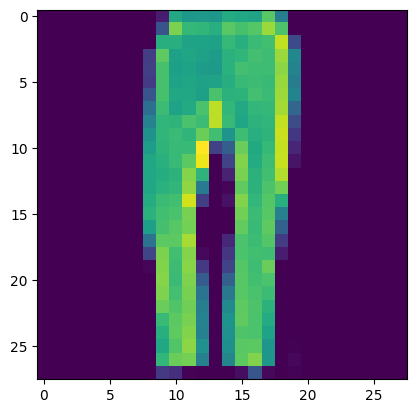

In [8]:
print(new_y[6025])
plt.imshow(new_train_set[6025].reshape(28,28))
plt.show()

In [9]:
backup = new_train_set.copy()
y_back = new_y.copy()

In [10]:
new_train_set = backup.copy()
new_y = y_back.copy()

In [38]:
#TODO: LOOK INTO CHANING VAR NAMES, X GETS OVERWRITTEN

#conv to tensors
np.random.seed(1)
torch.manual_seed(1)

#RANDOMLY PERMUTATE DATASET
indices = np.random.permutation(len(Y))
X = X[indices]
Y = Y[indices]

#SPLIT DATA INTO SPECIFIED REGIONS
test_set = X[0:7000] #10% of df, 7k data points
y_test = Y[0:7000]

valid_set = X[7000:14000] #10% of df, 7k data points
y_valid = Y[7000:14000]

#assemble our new training set, and add the original labeled set back
new_train_set = new_train_set.reshape(new_train_set.shape[0],28,28)
new_train_set = np.concatenate((new_train_set,labelled_train_set))
new_y = np.concatenate((new_y,y_labelled_train))

new_train_set = torch.tensor(new_train_set, dtype=torch.float32).to(DEVICE)
new_y = torch.tensor(new_y, dtype=torch.long).to(DEVICE)

test = torch.tensor(test_set, dtype=torch.float32).to(DEVICE)
y_test = torch.tensor(y_test, dtype=torch.long).to(DEVICE)
valid = torch.tensor(valid_set, dtype=torch.float32).to(DEVICE)
y_valid = torch.tensor(y_valid, dtype=torch.long).to(DEVICE)

/tmp/ipython-input-1981198697.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test = torch.tensor(test_set, dtype=torch.float32).to(DEVICE)
/tmp/ipython-input-1981198697.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.long).to(DEVICE)
/tmp/ipython-input-1981198697.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid = torch.tensor(valid_set, dtype=torch.float32).to(DEVICE)
/tmp/ipython-input-1981198697.py:30: UserWarning: To copy construct from a tensor, it is recommended to use so

In [41]:
new_train_set.shape

torch.Size([30258, 28, 28])

In [42]:

for w in range(1):
  #INSTANTIATE MODEL
  model = NeuralNetwork().to(DEVICE)
  model.apply(weights_init)

  #DEFINE CRITERIA AND OPTIMIZER
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE ,momentum = MOMENTUM) #m = 0.5,0.99; lr = 0.001, 0.1
  #optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  scheduler = None
  if ALR == "exp_decay":
    scheduler = ExponentialLR(optimizer, gamma=GAMMA)
  elif ALR == "factor_decay":
    scheduler = StepLR(optimizer, step_size=25, gamma=0.1)

  #NORMALIZE VALID AND TEST HERE B/C THEY AREN'T BEING AUGMENTED
  if NORMALIZATION == "minmax":
      test_ = test / 255.0 #TODO: REMOVE THIS FROM THE PREV CODE
      valid = valid / 255.0
      #new_train_set = new_train_set /255.0
  elif NORMALIZATION == "zscore":
      # Simple Z-score approximation
      valid = (valid - valid.mean()) / valid.std()
      test = (test - test.mean()) / test.std()
      #new_train_set = (new_train_set - new_train_set.mean()) / new_train_set.std()

  #DEFINE VARS FOR MINIBATCH GRADIENT DESCENT
  dataset = TensorDataset(new_train_set, new_y)
  dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

  #DATA COLLECTION FOR THIS SEED
  seed_train_loss, seed_valid_loss = [], []
  seed_train_acc, seed_valid_acc = [], []
  loss_history = np.zeros(OVERFITTING_DETECTION_PARAMETER)
  loss_history[loss_history == 0.0] = np.nan #fix this later

  #FORWARD PASS WITH INITIALIZED WEIGHTS
  for epoch in range(EPOCHS):
    model.train()

    #VARS FOR MINIBATCH STORAGE
    running_mean_loss = 0 #stores average loss over minibatches, so this is mean per epoch
    running_mean_acc = 0 #stores acc loss over minibatches, so this is acc per epoch
    count = 1 #counts minibatches

    #loads minibatch
    for x,y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        x = augmenter(x)
        # plt.imshow(x[0])
        # plt.show()

        if NORMALIZATION == "minmax":
            x = x / 255.0
        elif NORMALIZATION == "zscore":
            x = (x - x.mean()) / x.std()

        #forward pass and loss
        outputs = model(x)
        loss = criterion(outputs, y)

        #backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #get the loss and acc of the current minibatch
        minibatch_loss, minibatch_acc = eval_model(x, y,model,criterion)

        #store average loss and acc of minibatches
        running_mean_loss = running_mean_loss + (minibatch_loss - running_mean_loss) / count
        running_mean_acc = running_mean_acc + (minibatch_acc - running_mean_acc) / count
        count += 1

    #store the minibatch averages as per-epoch averages
    seed_train_loss.append(running_mean_loss)
    seed_train_acc.append(running_mean_acc)

    #validation
    model.eval()
    valid_loss, valid_acc = eval_model(valid, y_valid,model,criterion)

    seed_valid_loss.append(valid_loss)
    seed_valid_acc.append(valid_acc)

      #display avg. training loss
    if (epoch + 1) % 10 == 0:
      print(f'Epoch {epoch + 1}, Loss: {running_mean_loss:.4f}')
      print(f'Acc: {valid_acc:.4f}')

    loss_history[epoch%OVERFITTING_DETECTION_PARAMETER] = valid_loss

    #check overfitting
    mean = np.nanmean(loss_history)
    std = np.nanstd(loss_history)
    if valid_loss > mean + std or epoch == EPOCHS-1:
      print('overfitting',epoch,valid_loss,valid_acc)
      results['converge_time'].append(epoch)
      break

    if ALR == "exp_decay" or ALR == "factor_decay":
      scheduler.step() #decay learning rate
      # current_lr = optimizer.param_groups[0]['lr']
      # print(f"Current Learning Rate: {current_lr}")

  results['train_loss'].append(seed_train_loss)
  results['valid_loss'].append(seed_valid_loss)
  results["train_acc"].append(seed_train_acc)
  results["valid_acc"].append(seed_valid_acc)

  #TESTING
  logits = model(test)
  pred_probab = torch.nn.Softmax(dim=1)(logits)
  y_pred = pred_probab.argmax(1)
  print(f"Predicted class: {y_pred}")

  _,final_acc = eval_model(test,y_test,model,criterion)

  results["test_acc"].append(final_acc)


Epoch 10, Loss: 0.4744
Acc: 0.8060
Epoch 20, Loss: 0.4007
Acc: 0.8344
Epoch 30, Loss: 0.3712
Acc: 0.8433
Epoch 40, Loss: 0.3503
Acc: 0.8536
overfitting 43 0.4009811282157898 0.8484285714285714
Predicted class: tensor([2, 2, 0,  ..., 8, 8, 2])
